# Unsupervised Copy–Move Image Forgery Detection (Preliminary)

This project develops an unsupervised computer-vision pipeline for detecting copy–move manipulation. A copy–move forgery occurs when a region from an image is copied and pasted elsewhere within the same image.

The detector does not learn from labelled examples. Instead, it searches for groups of visually similar image patches that appear at different locations but share a consistent spatial displacement.

## Main methods

- Overlapping image patch extraction
- Patch standardisation
- Principal Component Analysis (PCA)
- Nearest-neighbour similarity matching
- DBSCAN displacement clustering
- Pixel-level localisation and evaluation
- Pristine image negative control

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.datasets import load_sample_image
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

SEED = 42
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Constructing a controlled forensic experiment

A sample photograph is loaded and converted to grayscale. One rectangular region is copied to another location with a small brightness adjustment.

Because the manipulation is created programmatically, the exact source and destination regions are known. These regions form a ground-truth mask used only for evaluation—not for training or detection.

In [3]:
rgb = np.asarray(
    Image.fromarray(load_sample_image("china.jpg")).resize(
        (256, 256), Image.Resampling.LANCZOS
    )
) / 255.0

clean_image = rgb[..., :3] @ np.array([0.299, 0.587, 0.114])

source = (40, 28, 56)
target = (152, 168, 56)
sr, sc, size = source
tr, tc, _ = target

tampered_image = clean_image.copy()
copied_region = clean_image[sr:sr + size, sc:sc + size]
tampered_image[tr:tr + size, tc:tc + size] = np.clip(copied_region * 1.03 + 0.01, 0, 1)

ground_truth = np.zeros_like(clean_image, dtype=bool)
ground_truth[sr:sr + size, sc:sc + size] = True
ground_truth[tr:tr + size, tc:tc + size] = True

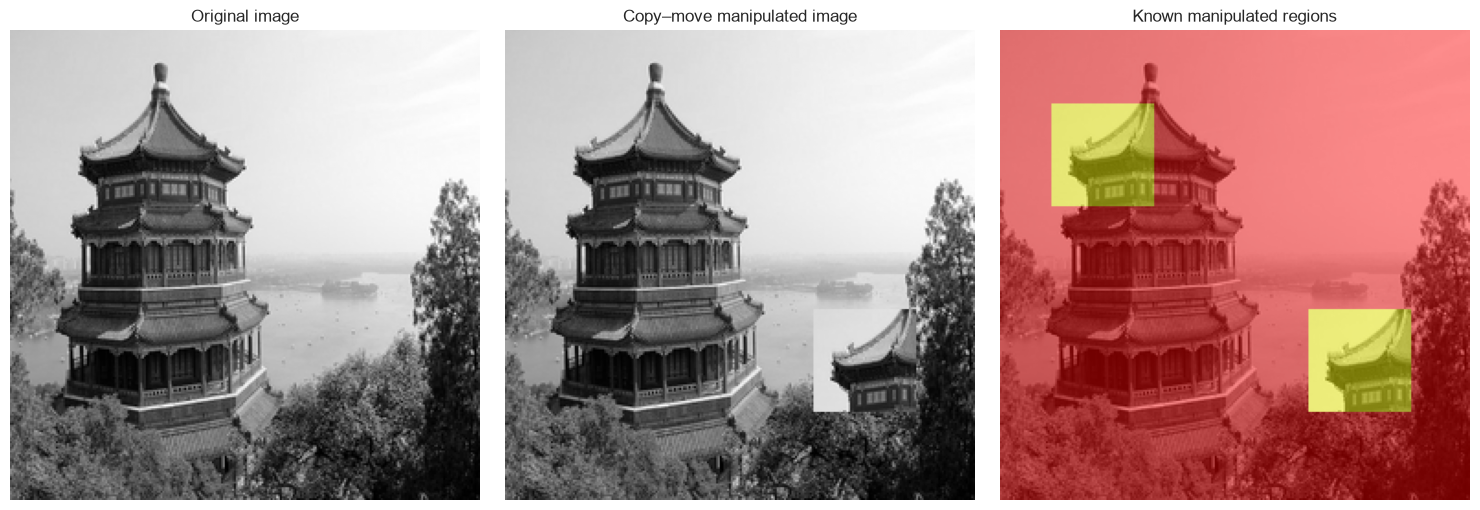

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(clean_image, cmap="gray")
axes[0].set_title("Original image")

axes[1].imshow(tampered_image, cmap="gray")
axes[1].set_title("Copy–move manipulated image")

axes[2].imshow(tampered_image, cmap="gray")
axes[2].imshow(ground_truth, cmap="autumn", alpha=0.45)
axes[2].set_title("Known manipulated regions")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data construction notes — replace after execution

- The source region was copied from: **[row, column]**
- The destination region was placed at: **[row, column]**
- The copied area measured: **[width × height] pixels**
- Visual observations: **[Describe whether the manipulation is easy to see manually.]**

The ground-truth mask contains both the original source region and the pasted destination because a copy–move detector should ideally locate both sides of the duplication.

## 2. Extracting unsupervised patch features

The image is divided into many overlapping patches. Each patch is standardised separately, reducing sensitivity to basic brightness and contrast changes.

PCA then compresses every patch into a smaller feature vector. This retains major structural information such as edges and textures while removing redundant pixel information.

PCA is fitted directly to the image patches without using manipulation labels.

In [5]:
def extract_features(image, patch_size=16, stride=4, n_components=32):
    grid = np.lib.stride_tricks.sliding_window_view(
        image, (patch_size, patch_size)
    )[::stride, ::stride]

    n_rows, n_cols = grid.shape[:2]
    patches = grid.reshape(-1, patch_size ** 2)
    patches = (patches - patches.mean(axis=1, keepdims=True)) / (
        patches.std(axis=1, keepdims=True) + 1e-8
    )

    pca = PCA(
        n_components=n_components,
        svd_solver="randomized",
        random_state=SEED
    )
    features = pca.fit_transform(patches)

    coordinates = np.column_stack([
        np.repeat(np.arange(n_rows) * stride, n_cols),
        np.tile(np.arange(n_cols) * stride, n_rows)
    ])

    return features, coordinates, pca

In [6]:
features, coordinates, pca = extract_features(tampered_image)

feature_summary = pd.DataFrame({
    "measurement": [
        "Number of patches",
        "Original patch dimensions",
        "PCA dimensions",
        "Variance retained"
    ],
    "value": [
        len(features),
        16 * 16,
        features.shape[1],
        pca.explained_variance_ratio_.sum()
    ]
})

feature_summary

,measurement,value
0,Number of patches,3721.000000
1,Original patch dimensions,256.000000
2,PCA dimensions,32.000000
3,Variance retained,0.746917


### Data construction notes

- The source region began at **row 40, column 28**.
- The destination region began at **row 152, column 168**.
- Each duplicated region measured **56 × 56 pixels**.
- The copied content moved **112 rows downward and 140 columns to the right**.
- A small brightness transformation was applied to the pasted region, making the task more realistic than detecting an identical pixel-for-pixel copy.

The manipulation affects a relatively small part of the complete image. The ground-truth overlay clearly identifies both the original source and pasted destination regions. Both regions are included because copy–move detection aims to identify the pair of duplicated areas.

### Feature extraction 

- Number of overlapping patches: **3,721**
- Original features per patch: **256 pixels**
- PCA features per patch: **32 components**
- Total variance retained: **0.7469, or approximately 74.69%**

PCA reduced each patch from 256 to 32 dimensions, representing an **87.5% reduction in dimensionality** while retaining nearly three-quarters of the original variation.

This provides a substantially smaller representation for similarity matching while preserving much of the structural information contained in the patches. Some fine detail was discarded, but the retained information was sufficient to detect the duplicated region accurately.

## 3. Finding suspicious patch pairs

Nearest Neighbours finds patches with similar PCA representations. Matches located very close together are ignored because adjacent patches naturally overlap and resemble one another.

Only the strongest fraction of distant matches is retained. For every retained pair, a displacement vector is calculated

A genuine copy–move operation should create many matches with approximately the same displacement.

In [7]:
def find_matches(features, coordinates, neighbors=6, min_separation=40, distance_quantile=0.02):
    distances, indices = NearestNeighbors(
        n_neighbors=neighbors
    ).fit(features).kneighbors(features)

    records = []

    for i in range(len(features)):
        for distance, j in zip(distances[i, 1:], indices[i, 1:]):
            if j <= i:
                continue

            dr, dc = coordinates[j] - coordinates[i]

            if np.hypot(dr, dc) >= min_separation:
                records.append((i, j, distance, dr, dc))

    all_matches = pd.DataFrame(
        records,
        columns=["patch_a", "patch_b", "distance", "dr", "dc"]
    )

    cutoff = all_matches["distance"].quantile(distance_quantile)
    selected = all_matches[all_matches["distance"] <= cutoff].reset_index(drop=True)

    return selected, cutoff

In [8]:
def run_detector(image, patch_size=16, stride=4, distance_quantile=0.02):
    features, coordinates, pca = extract_features(image, patch_size, stride)
    matches, cutoff = find_matches(
        features, coordinates,
        distance_quantile=distance_quantile
    )

    matches["cluster"] = DBSCAN(
        eps=2,
        min_samples=4
    ).fit_predict(matches[["dr", "dc"]])

    counts = matches.loc[
        matches["cluster"] >= 0, "cluster"
    ].value_counts()

    best_cluster = int(counts.index[0]) if len(counts) else None

    if best_cluster is None:
        selected = matches.iloc[0:0].copy()
    else:
        selected = matches[matches["cluster"] == best_cluster].copy()

    heatmap = np.zeros_like(image, dtype=float)

    for match in selected.itertuples():
        for patch_id in (match.patch_a, match.patch_b):
            row, column = coordinates[patch_id]
            heatmap[
                row:row + patch_size,
                column:column + patch_size
            ] += 1

    return {
        "features": features,
        "coordinates": coordinates,
        "pca": pca,
        "matches": matches,
        "selected": selected,
        "cutoff": cutoff,
        "heatmap": heatmap,
        "mask": heatmap > 0,
        "largest_cluster": len(selected)
    }

In [9]:
result = run_detector(tampered_image)

clustered_matches = result["matches"][
    result["matches"]["cluster"] >= 0
]

cluster_summary = (
    clustered_matches.groupby("cluster")
    .agg(
        match_count=("cluster", "size"),
        mean_row_shift=("dr", "mean"),
        mean_column_shift=("dc", "mean"),
        mean_distance=("distance", "mean")
    )
    .reset_index()
    .sort_values("match_count", ascending=False)
)

print("Similarity cutoff:", result["cutoff"])
print("Largest displacement cluster:", result["largest_cluster"])
cluster_summary.head(10)

Similarity cutoff: 2.5887825616737383
Largest displacement cluster: 72


,cluster,match_count,mean_row_shift,mean_column_shift,mean_distance
0,0,72,112.0,140.0,0.089138
1,1,4,0.0,44.0,1.904183
2,2,4,0.0,52.0,1.938320
3,3,4,0.0,60.0,1.856560


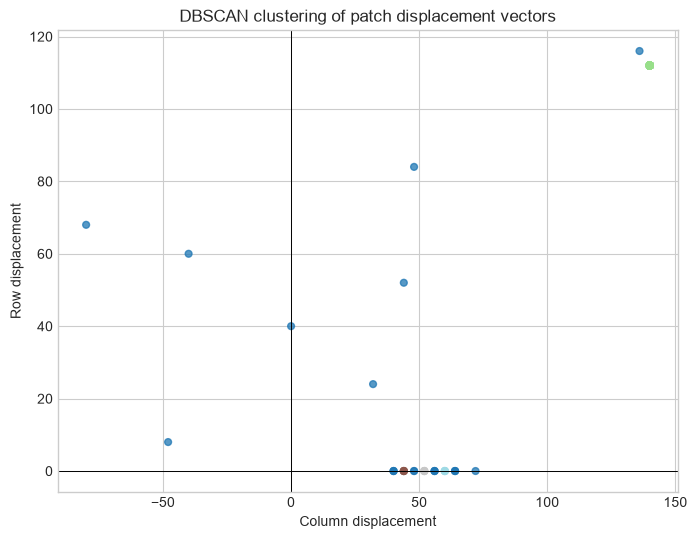

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    result["matches"]["dc"],
    result["matches"]["dr"],
    c=result["matches"]["cluster"],
    cmap="tab20",
    s=24,
    alpha=0.75
)

plt.xlabel("Column displacement")
plt.ylabel("Row displacement")
plt.title("DBSCAN clustering of patch displacement vectors")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.show()

### Patch matching and clustering notes

- Similarity-distance cutoff: **2.5888**
- Matches assigned to non-noise DBSCAN clusters: **84**
- Size of the dominant displacement cluster: **72 matches**
- Estimated row displacement: **112 pixels**
- Estimated column displacement: **140 pixels**
- Mean feature distance within the dominant cluster: **0.0891**

The estimated displacement of **(112, 140)** exactly matches the known movement from the source location at `(40, 28)` to the destination at `(152, 168)`.

The dominant cluster contained 72 matches, whereas each of the three secondary clusters contained only four. Its mean feature distance of 0.0891 was also much smaller than the approximately 1.86–1.94 distances of the secondary clusters. This provides strong evidence that the dominant cluster represents a genuine duplicated region rather than accidental similarities.

The saved output does not display the total number of retained candidates, including DBSCAN noise points. It confirms that 84 candidates were assigned to non-noise clusters.

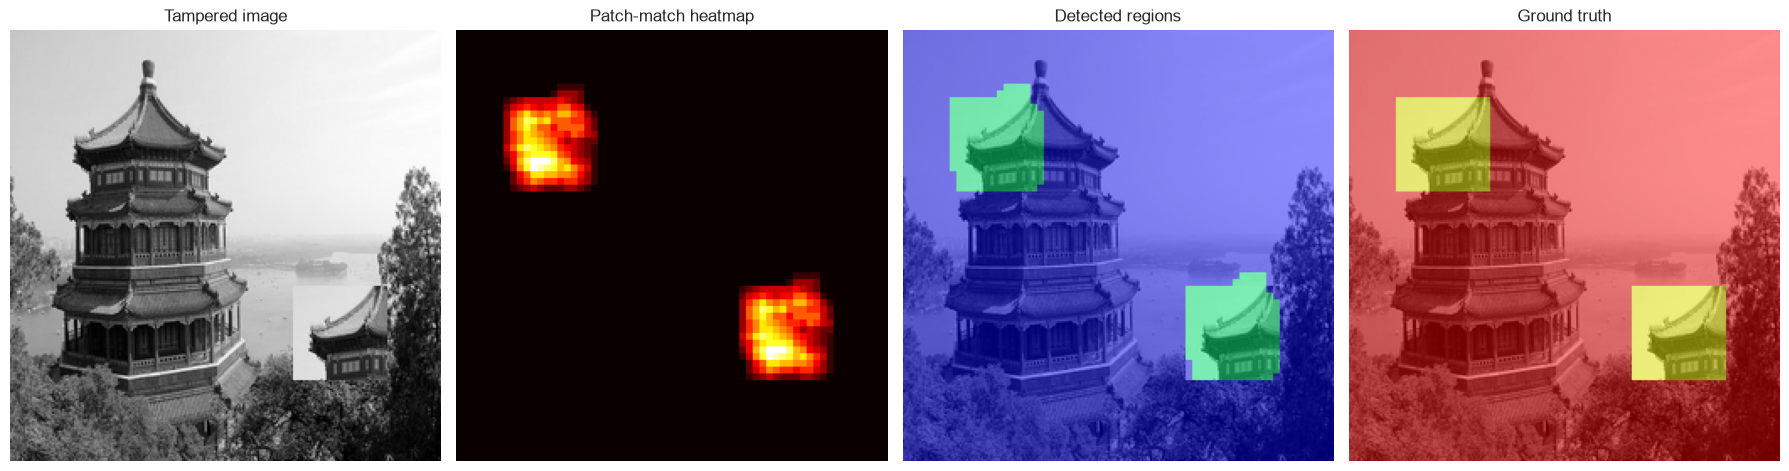

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(tampered_image, cmap="gray")
axes[0].set_title("Tampered image")

axes[1].imshow(result["heatmap"], cmap="hot")
axes[1].set_title("Patch-match heatmap")

axes[2].imshow(tampered_image, cmap="gray")
axes[2].imshow(result["mask"], cmap="winter", alpha=0.45)
axes[2].set_title("Detected regions")

axes[3].imshow(tampered_image, cmap="gray")
axes[3].imshow(ground_truth, cmap="autumn", alpha=0.45)
axes[3].set_title("Ground truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

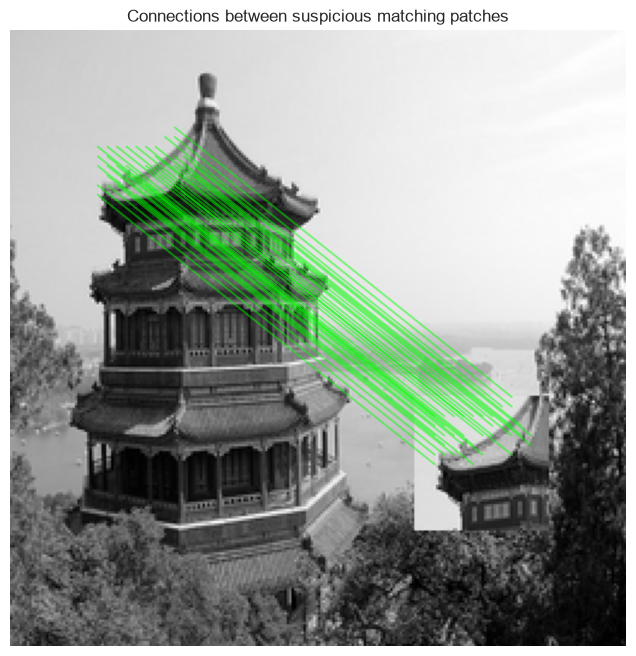

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(tampered_image, cmap="gray")

for match in result["selected"].head(35).itertuples():
    r1, c1 = result["coordinates"][match.patch_a]
    r2, c2 = result["coordinates"][match.patch_b]
    ax.plot([c1 + 8, c2 + 8], [r1 + 8, r2 + 8], color="lime", alpha=0.45)

ax.set_title("Connections between suspicious matching patches")
ax.axis("off")
plt.show()

## 4. Pixel-level evaluation

Because the experiment has a known manipulation mask, the localisation can be evaluated using:

- **Precision:** how much of the detected area is genuinely manipulated.
- **Recall:** how much of the known manipulated area was found.
- **F1-score:** balance between precision and recall.
- **Intersection over Union:** overlap between the predicted and true regions.

These labels are used only after detection for evaluation.

In [13]:
predicted = result["mask"].ravel()
actual = ground_truth.ravel()

metrics_df = pd.DataFrame({
    "Precision": [precision_score(actual, predicted, zero_division=0)],
    "Recall": [recall_score(actual, predicted, zero_division=0)],
    "F1-score": [f1_score(actual, predicted, zero_division=0)],
    "IoU": [jaccard_score(actual, predicted, zero_division=0)]
}, index=["Copy–move detector"])

metrics_df.round(4)

,Precision,Recall,F1-score,IoU
Copy–move detector,0.9545,0.9643,0.9594,0.922


## 5. Pristine image negative control

A useful detector should produce much stronger evidence for a manipulated image than for an untouched image.

The same pipeline is therefore applied to the original photograph. Some accidental matches are expected because images contain repeated textures, but they should not form a displacement cluster as large as the copy–move cluster.

In [14]:
clean_result = run_detector(clean_image)

control_df = pd.DataFrame({
    "image": ["Tampered image", "Pristine image"],
    "largest_displacement_cluster": [
        result["largest_cluster"],
        clean_result["largest_cluster"]
    ],
    "detected_pixels": [
        result["mask"].sum(),
        clean_result["mask"].sum()
    ]
})

control_df["cluster_ratio_to_pristine"] = (
    control_df["largest_displacement_cluster"] /
    max(clean_result["largest_cluster"], 1)
)

control_df

,image,largest_displacement_cluster,detected_pixels,cluster_ratio_to_pristine
0,Tampered image,72,6336,10.285714
1,Pristine image,7,1184,1.000000


In [15]:
sensitivity_rows = []

for quantile in [0.005, 0.01, 0.02, 0.04]:
    output = run_detector(tampered_image, distance_quantile=quantile)

    sensitivity_rows.append({
        "distance_quantile": quantile,
        "largest_cluster": output["largest_cluster"],
        "precision": precision_score(actual, output["mask"].ravel(), zero_division=0),
        "recall": recall_score(actual, output["mask"].ravel(), zero_division=0),
        "f1_score": f1_score(actual, output["mask"].ravel(), zero_division=0),
        "iou": jaccard_score(actual, output["mask"].ravel(), zero_division=0)
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.round(4)

,distance_quantile,largest_cluster,precision,recall,f1_score,iou
0,0.005,28,1.0000,0.7959,0.8864,0.7959
1,0.010,56,1.0000,0.8878,0.9405,0.8878
2,0.020,72,0.9545,0.9643,0.9594,0.9220
3,0.040,72,0.9545,0.9643,0.9594,0.9220


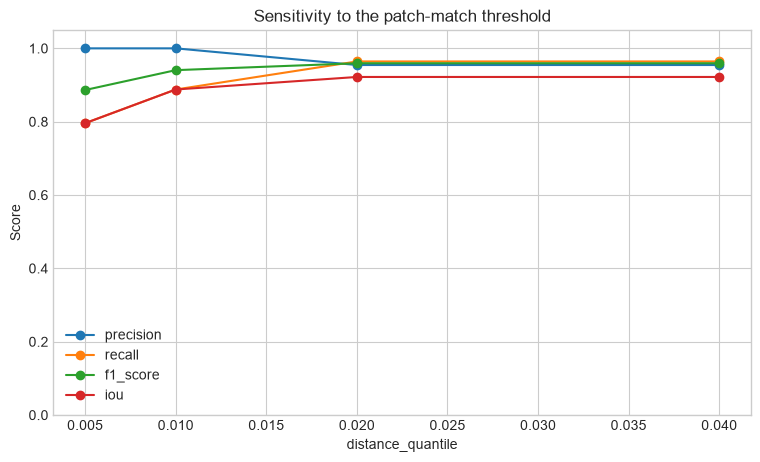

In [16]:
sensitivity_df.plot(
    x="distance_quantile",
    y=["precision", "recall", "f1_score", "iou"],
    marker="o",
    figsize=(9, 5)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Sensitivity to the patch-match threshold")
plt.show()

## Results and interpretation

### Localisation performance

- Precision: **0.9545**
- Recall: **0.9643**
- F1-score: **0.9594**
- Intersection over Union: **0.9220**

The detector correctly identified approximately **96.43% of the known duplicated area**. Its precision of 95.45% indicates that only a small proportion of the detected pixels fell outside the ground-truth regions.

Of the 6,272 ground-truth pixels, approximately **6,048 were correctly detected**, 224 were missed and 288 additional pixels were incorrectly included. These small boundary errors are expected because the detector localises overlapping square patches rather than predicting each pixel independently.

### Pristineimage comparison

- Largest cluster in the manipulated image: **72 matches**
- Largest cluster in the pristine image: **7 matches**
- Dominant-cluster ratio: **10.29**
- Detected pixels in the manipulated image: **6,336**
- Detected pixels in the pristine image: **1,184**

The manipulated image produced a dominant cluster more than ten times the size of the largest cluster found in the pristine image. The pristine image still produced a few accidental matches because natural photographs contain repeated edges and textures, but these matches did not form a comparably strong displacement pattern.

### Threshold sensitivity

At the strictest quantile of 0.005, precision was perfect at 1.0000, but recall fell to 0.7959 because many genuine matches were excluded. Increasing the quantile improved coverage:

- **0.005:** F1 = 0.8864 and IoU = 0.7959
- **0.010:** F1 = 0.9405 and IoU = 0.8878
- **0.020:** F1 = 0.9594 and IoU = 0.9220
- **0.040:** F1 = 0.9594 and IoU = 0.9220

The best results were obtained at 0.020 and 0.040. Since increasing the threshold beyond 0.020 produced no improvement, **0.020 is the preferable setting** because it is more selective while achieving the same performance.

### Final conclusion

The unsupervised detector successfully located both duplicated regions and recovered their exact spatial displacement. PCA produced a compact patch representation, nearest-neighbour matching identified visually similar patches, and DBSCAN separated the dominant copy–move pattern from small accidental groups.

The high F1-score of **0.9594**, IoU of **0.9220**, exact displacement recovery and substantially weaker pristine-image cluster all support successful detection in this controlled experiment.

However, the experiment uses one synthetic copy–move example. Therefore, the results demonstrate that the pipeline works under these controlled conditions but do not yet establish its reliability across diverse real-world manipulations.

## Project limitations

This detector is designed specifically for copy–move manipulation within one image. It does not directly detect deepfakes or content copied from another photograph.

Possible limitations include:

- naturally repeated windows, tiles or textures creating false matches;
- copied regions being rotated or resized;
- heavy compression or blurring changing patch appearance;
- small manipulations containing too few matching patches;
- imperfect region boundaries caused by overlapping patch localisation.

Future improvements could use rotation-invariant descriptors, multi-scale patches, image keypoints or morphological post-processing.